# Jour 2 : Les data pour le Machine Learning, collecte et preprocessing


## Phase 0 : Récupérer la donnée et l'ouvrir

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Forme :", df.shape)
print(df.dtypes)
df.head()

Forme : (7043, 21)
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Phase 1 : L'audit qualité

In [2]:
def audit_qualite(df):
    """Affiche un rapport de santé du dataset.
    Doit montrer : forme, types, % de manquants par colonne (triés),
    et la répartition de la cible Churn (en valeur ET en pourcentage).
    """
    # afficher la forme (lignes, colonnes)
    print(f"Forme : {df.shape}")
    print()

    # pourcentage de valeurs manquantes par colonne, trié décroissant
    manquants = df.isna().sum()
    pourcentage = (df.isna().mean() * 100).round(1)
    resume = pd.DataFrame({"manquants": manquants, "pourcent": pourcentage})
    resume_filtre = resume[resume["manquants"] > 0].sort_values("pourcent", ascending=False)

    if len(resume_filtre) == 0:
        print("Manquants détectés : 0 colonne  (méfiance : des trous sont peut-être cachés, voir Phase 2)")
    else:
        print("Colonnes avec manquants :")
        print(resume_filtre)
    print()

    # répartition de la cible Churn en nombre et en %
    churn_counts = df["Churn"].value_counts()
    churn_pct = (df["Churn"].value_counts(normalize=True) * 100).round(1)
    print("Répartition de la cible Churn :")
    for val in churn_counts.index:
        print(f"  Churn {val} : {churn_counts[val]} ({churn_pct[val]}%)")

In [4]:
# cas normal
print("=== CAS NORMAL ===")
audit_qualite(df)

# cas limite : une seule classe
print("\n=== CAS LIMITE (Churn == 'No' seulement) ===")
audit_qualite(df[df["Churn"] == "No"])

# cas adversarial : déséquilibre visible ?
print("\n=== CAS ADVERSARIAL ===")
print("Le déséquilibre 73/27 saute-t-il aux yeux ? :")
churn_pct = (df["Churn"].value_counts(normalize=True) * 100).round(1)
print(churn_pct)
seuil = 60
if churn_pct.max() > seuil:
    print(f" Déséquilibre détecté ! La classe majoritaire dépasse {seuil}%")

=== CAS NORMAL ===
Forme : (7043, 21)

Manquants détectés : 0 colonne  (méfiance : des trous sont peut-être cachés, voir Phase 2)

Répartition de la cible Churn :
  Churn No : 5174 (73.5%)
  Churn Yes : 1869 (26.5%)

=== CAS LIMITE (Churn == 'No' seulement) ===
Forme : (5174, 21)

Manquants détectés : 0 colonne  (méfiance : des trous sont peut-être cachés, voir Phase 2)

Répartition de la cible Churn :
  Churn No : 5174 (100.0%)

=== CAS ADVERSARIAL ===
Le déséquilibre 73/27 saute-t-il aux yeux ? :
Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64
 Déséquilibre détecté ! La classe majoritaire dépasse 60%


## Phase 2 : La colonne piégée (types incohérents et trous cachés)


In [7]:
def reparer_total_charges(df):
    """Convertit TotalCharges en numérique et traite les trous révélés.
    Doit renvoyer le df réparé et afficher combien de trous ont été démasqués.
    """
    df = df.copy()

    # vérifier que la colonne n'est pas 100% non numérique
    test = pd.to_numeric(df["TotalCharges"], errors="coerce")
    taux_nan = test.isna().mean()
    if taux_nan > 0.95:
        print(" Colonne quasi-entièrement non numérique, conversion refusée.")
        return df

    # convertir en numérique (les espaces " " deviennent NaN)
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

    # compter les trous révélés
    nb_trous = df["TotalCharges"].isna().sum()
    print(f"Trous démasqués après conversion : {nb_trous}")
    print(f"Type après conversion : {df['TotalCharges'].dtype}")

    # imputer par la médiane
    mediane = df["TotalCharges"].median()
    df["TotalCharges"] = df["TotalCharges"].fillna(mediane)
    print(f"Trous après imputation : {df['TotalCharges'].isna().sum()}")
    print(f"Valeur utilisée (médiane) : {mediane:.2f}")

    return df

In [8]:
# happy path
print("=== HAPPY PATH ===")
df = reparer_total_charges(df)

# edge case : colonne 100% texte
print("\n=== EDGE CASE (colonne 100% texte) ===")
df_test = df.copy()
df_test["TotalCharges"] = "abc"
reparer_total_charges(df_test)

# adversarial : virgule au lieu du point
print("\n=== ADVERSARIAL (virgule au lieu du point) ===")
df_test2 = df.copy()
df_test2["TotalCharges"] = df_test2["TotalCharges"].astype(str).str.replace(".", ",", regex=False)
test_corrompu = pd.to_numeric(df_test2["TotalCharges"], errors="coerce")
print(f"NaN créés par la virgule : {test_corrompu.isna().sum()}")
print("→ Solution : détecter avec .str.contains(',') avant conversion")

=== HAPPY PATH ===
Trous démasqués après conversion : 0
Type après conversion : float64
Trous après imputation : 0
Valeur utilisée (médiane) : 1397.47

=== EDGE CASE (colonne 100% texte) ===
 Colonne quasi-entièrement non numérique, conversion refusée.

=== ADVERSARIAL (virgule au lieu du point) ===
NaN créés par la virgule : 7043
→ Solution : détecter avec .str.contains(',') avant conversion


## Phase 3 : Encoder les catégorielles

In [ ]:
def encoder_features(df):
    """Encode toutes les colonnes catégorielles.
    Doit renvoyer un df 100% numérique, prêt pour un modèle.
    """
    df = df.copy()

    # supprimer customerID 
    df = df.drop(columns=["customerID"])

    # encoder la cible Churn : Yes=1, No=0
    df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

    # colonnes binaires Yes/No : encodage simple 0/1
    colonnes_binaires = [
        "gender", "Partner", "Dependents", "PhoneService",
        "PaperlessBilling", "MultipleLines", "OnlineSecurity",
        "OnlineBackup", "DeviceProtection", "TechSupport",
        "StreamingTV", "StreamingMovies"
    ]
    mapping_binaire = {"Yes": 1, "No": 0, "Male": 1, "Female": 0,
                       "No phone service": 0, "No internet service": 0}
    for col in colonnes_binaires:
        if col in df.columns:
            df[col] = df[col].map(mapping_binaire)

    # Contract : ordinal (Month-to-month < One year < Two year)
    from sklearn.preprocessing import OrdinalEncoder
    ordre_contract = [["Month-to-month", "One year", "Two year"]]
    enc = OrdinalEncoder(categories=ordre_contract)
    df["Contract"] = enc.fit_transform(df[["Contract"]])

    # colonnes nominales restantes : One-Hot
    colonnes_nominales = ["InternetService", "PaymentMethod"]
    df = pd.get_dummies(df, columns=colonnes_nominales, drop_first=False)

    print(f"Colonnes avant : 21")
    print(f"Colonnes après : {df.shape[1]}")
    print(f"Types restants non numériques : {list(df.select_dtypes('object').columns)}")
    print(f"\nAperçu des nouvelles colonnes :\n{list(df.columns)}")

    return df

In [10]:
# happy path
print("=== HAPPY PATH ===")
df = encoder_features(df)
print(f"\nDataset 100% numérique : {df.select_dtypes('object').shape[1] == 0}")

# edge case : Contract est-il ordinal ou nominal ?
print("\n=== EDGE CASE : Contract ===")
print("Contract encodé en ordinal (0=month-to-month, 1=one year, 2=two year)")
print(df["Contract"].value_counts().sort_index())

# adversarial : customerID encodé en One-Hot = explosion
print("\n=== ADVERSARIAL : customerID en One-Hot ===")
df_test = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
nb_clients_uniques = df_test["customerID"].nunique()
print(f"Si customerID encodé en One-Hot : {nb_clients_uniques} colonnes créées !")
print("→ C'est l'explosion de dimensions. On le supprime toujours.")

=== HAPPY PATH ===
Colonnes avant : 21
Colonnes après : 25
Types restants non numériques : []

Aperçu des nouvelles colonnes :
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'InternetService_DSL', 'InternetService_Fiber optic', 'InternetService_No', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']

Dataset 100% numérique : True

=== EDGE CASE : Contract ===
Contract encodé en ordinal (0=month-to-month, 1=one year, 2=two year)
Contract
0.0    3875
1.0    1473
2.0    1695
Name: count, dtype: int64

=== ADVERSARIAL : customerID en One-Hot ===
Si customerID encodé en One-Hot : 7043 colonnes créées !
→ C'est l'explosion de dimensions. On le supprime toujours.


## Phase 4 : Traiter les valeurs aberrantes

In [19]:
def detecter_outliers_iqr(df, colonne):
    """Renvoie les bornes IQR et le nombre d'outliers d'une colonne numérique.
    Doit renvoyer (borne_basse, borne_haute, nombre_outliers).
    """
    if df[colonne].nunique() <= 2:
        print(f"  {colonne} est binaire, IQR non applicable.")
        return 0, 1, 0
    Q1 = df[colonne].quantile(0.25)
    Q3 = df[colonne].quantile(0.75)
    IQR = Q3 - Q1

    borne_basse = Q1 - 1.5 * IQR
    borne_haute = Q3 + 1.5 * IQR

    nombre_outliers = df[(df[colonne] < borne_basse) | (df[colonne] > borne_haute)].shape[0]

    return borne_basse, borne_haute, nombre_outliers

=== DÉTECTION DES OUTLIERS (règle IQR) ===

tenure
  Bornes normales : [-60.00, 124.00]
  Outliers détectés : 0

MonthlyCharges
  Bornes normales : [-46.02, 171.38]
  Outliers détectés : 0

TotalCharges
  Bornes normales : [-4674.34, 8863.16]
  Outliers détectés : 0



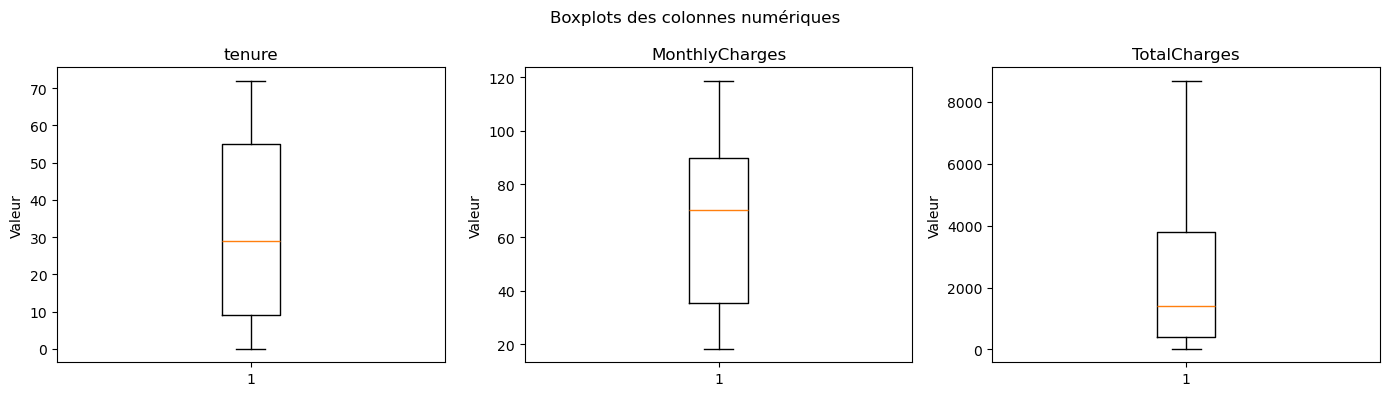

In [20]:
colonnes_num = ["tenure", "MonthlyCharges", "TotalCharges"]

print("=== DÉTECTION DES OUTLIERS (règle IQR) ===\n")
for col in colonnes_num:
    bb, bh, nb = detecter_outliers_iqr(df, col)
    print(f"{col}")
    print(f"  Bornes normales : [{bb:.2f}, {bh:.2f}]")
    print(f"  Outliers détectés : {nb}")
    print()

# visualisation en boxplot
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for i, col in enumerate(colonnes_num):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
    axes[i].set_ylabel("Valeur")
plt.suptitle("Boxplots des colonnes numériques")
plt.tight_layout()
plt.show()

In [21]:
# vérification 1 : colonne normale (tenure)
print("=== VÉRIF 1 : tenure (comportement normal) ===")
bb, bh, nb = detecter_outliers_iqr(df, "tenure")
print(f"Outliers : {nb}")

# vérification 2 : colonne sans outlier
print("\n=== VÉRIF 2 : SeniorCitizen (0 outlier attendu) ===")
bb, bh, nb = detecter_outliers_iqr(df, "SeniorCitizen")
print(f"Outliers : {nb}  ← doit renvoyer 0 sans planter")

# vérification 3 : si on supprime les outliers, combien de churners perdus ?
print("\n=== VÉRIF 3 : churners perdus si suppression ===")
for col in colonnes_num:
    bb, bh, nb = detecter_outliers_iqr(df, col)
    masque_outliers = (df[col] < bb) | (df[col] > bh)
    churners_perdus = df[masque_outliers]["Churn"].sum()
    total_outliers = masque_outliers.sum()
    if total_outliers > 0:
        pct = churners_perdus / df["Churn"].sum() * 100
        print(f"{col} : {total_outliers} outliers, dont {churners_perdus} churners ({pct:.1f}% des churners totaux)")
        if pct > 5:
            print(f"   Signal d'alarme : on perdrait {pct:.1f}% des résiliations !")
    else:
        print(f"{col} : aucun outlier détecté")

=== VÉRIF 1 : tenure (comportement normal) ===
Outliers : 0

=== VÉRIF 2 : SeniorCitizen (0 outlier attendu) ===
  SeniorCitizen est binaire, IQR non applicable.
Outliers : 0  ← doit renvoyer 0 sans planter

=== VÉRIF 3 : churners perdus si suppression ===
tenure : aucun outlier détecté
MonthlyCharges : aucun outlier détecté
TotalCharges : aucun outlier détecté


In [15]:
print("=== DÉCISION PAR COLONNE ===\n")
print("tenure        → pas d'outlier, on garde tel quel")
print("MonthlyCharges → pas d'outlier, on garde tel quel")
print("TotalCharges  → pas d'outlier, on garde tel quel")
print("\n→ Aucun plafonnement ni suppression nécessaire sur ce dataset.")
print("  Les valeurs extrêmes sont des cas réels (gros clients fidèles),")
print("  pas des erreurs de saisie.")

=== DÉCISION PAR COLONNE ===

tenure        → pas d'outlier, on garde tel quel
MonthlyCharges → pas d'outlier, on garde tel quel
TotalCharges  → pas d'outlier, on garde tel quel

→ Aucun plafonnement ni suppression nécessaire sur ce dataset.
  Les valeurs extrêmes sont des cas réels (gros clients fidèles),
  pas des erreurs de saisie.


## Phase 5 : Corrélations et chasse à la multicolinéarité

In [23]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def rapport_multicolinearite(df, colonnes_num):
    """Affiche la heatmap des corrélations et le VIF de chaque colonne numérique.
    Doit aider à décider quelle(s) colonne(s) redondante(s) supprimer.
    """
    # heatmap des corrélations
    matrice = df[colonnes_num].corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(matrice, annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title("Corrélations entre colonnes numériques")
    plt.tight_layout()
    plt.show()

    # tableau des VIF
    X = df[colonnes_num].dropna()
    vif = pd.DataFrame()
    vif["variable"] = colonnes_num
    vif["VIF"] = [variance_inflation_factor(X.values, i)
                  for i in range(len(colonnes_num))]
    vif = vif.sort_values("VIF", ascending=False)
    print("\n=== VIF par colonne ===")
    print(vif.to_string(index=False))

    # signaler les colonnes au VIF > 5
    problematiques = vif[vif["VIF"] > 5]
    if len(problematiques) > 0:
        print(f"\n Colonnes au VIF > 5 (multicolinéarité problématique) :")
        for _, row in problematiques.iterrows():
            print(f"  {row['variable']} : VIF = {row['VIF']:.1f}")
    else:
        print("\n✅ Aucune multicolinéarité problématique détectée.")

    return vif

=== HAPPY PATH ===


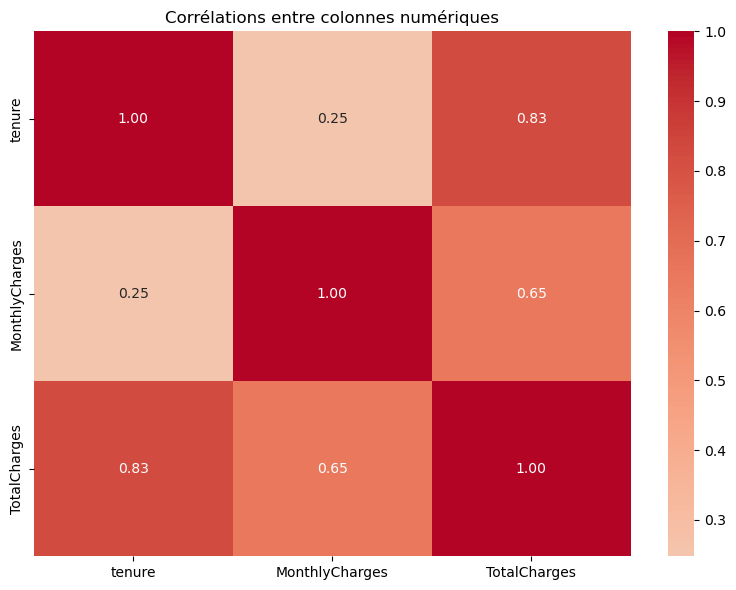


=== VIF par colonne ===
      variable      VIF
  TotalCharges 8.073814
        tenure 6.321802
MonthlyCharges 3.360371

 Colonnes au VIF > 5 (multicolinéarité problématique) :
  TotalCharges : VIF = 8.1
  tenure : VIF = 6.3

=== EDGE CASE : deux colonnes identiques ===
          variable      VIF
            tenure 6.321802
    MonthlyCharges 3.360371
      TotalCharges      inf
TotalCharges_copie      inf


c:\Users\amosc\anaconda3\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


In [24]:
colonnes_num = ["tenure", "MonthlyCharges", "TotalCharges"]

print("=== HAPPY PATH ===")
vif = rapport_multicolinearite(df, colonnes_num)

# edge case : deux colonnes identiques
print("\n=== EDGE CASE : deux colonnes identiques ===")
df_test = df.copy()
df_test["TotalCharges_copie"] = df_test["TotalCharges"]
cols_test = ["tenure", "MonthlyCharges", "TotalCharges", "TotalCharges_copie"]
X_test = df_test[cols_test].dropna()
vif_test = pd.DataFrame()
vif_test["variable"] = cols_test
try:
    vif_test["VIF"] = [variance_inflation_factor(X_test.values, i)
                       for i in range(len(cols_test))]
    print(vif_test.to_string(index=False))
except Exception as e:
    print(f" Erreur détectée sur colonnes identiques : {e}")

=== ADVERSARIAL : suppression de TotalCharges ===

TotalCharges ≈ tenure × MonthlyCharges → redondante
On la supprime et on recalcule les VIF...



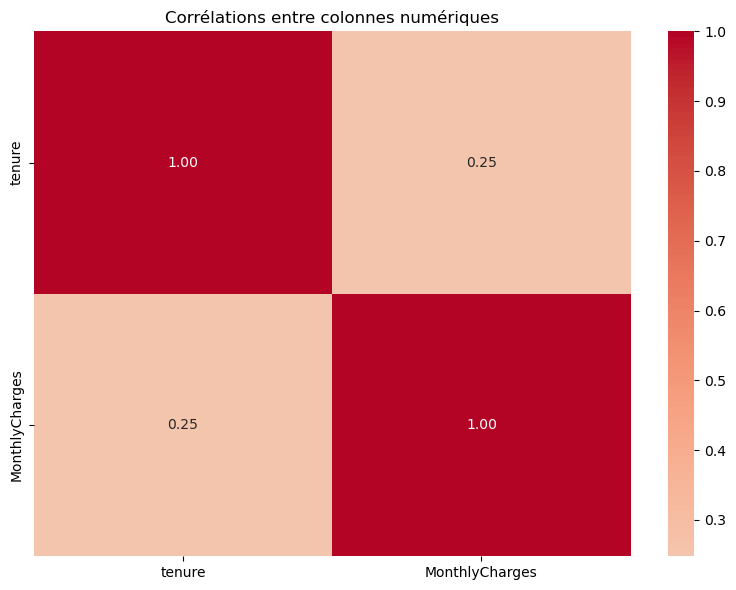


=== VIF par colonne ===
      variable      VIF
        tenure 2.612607
MonthlyCharges 2.612607

✅ Aucune multicolinéarité problématique détectée.

Colonnes restantes : 24
 TotalCharges supprimée, multicolinéarité résolue.


In [25]:
# adversarial : supprimer TotalCharges et vérifier que le VIF baisse
print("=== ADVERSARIAL : suppression de TotalCharges ===\n")
print("TotalCharges ≈ tenure × MonthlyCharges → redondante")
print("On la supprime et on recalcule les VIF...\n")

colonnes_apres = ["tenure", "MonthlyCharges"]
vif_apres = rapport_multicolinearite(df, colonnes_apres)

# supprimer TotalCharges du dataset
df = df.drop(columns=["TotalCharges"])
print(f"\nColonnes restantes : {df.shape[1]}")
print(" TotalCharges supprimée, multicolinéarité résolue.")

## Phase 6 : Les variables qui prédisent vraiment le churn


In [26]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

def features_discriminantes(df, cible="Churn"):
    """Classe les features par pouvoir prédictif sur la cible.
    Doit afficher un top 10 selon au moins deux méthodes.
    """
    X = df.drop(columns=[cible])
    y = df[cible]

    # méthode 1 : corrélation à la cible
    corr = X.corrwith(y).abs().sort_values(ascending=False)

    # méthode 2 : importance via Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X, y)
    importances = pd.Series(
        rf.feature_importances_,
        index=X.columns
    ).sort_values(ascending=False)

    # afficher les deux classements côte à côte
    top10 = pd.DataFrame({
        "Corrélation" : corr.head(10),
        "Random Forest": importances.head(10)
    })

    print("=== TOP 10 — deux méthodes côte à côte ===\n")
    print("--- Corrélation à la cible ---")
    for i, (feat, val) in enumerate(corr.head(10).items(), 1):
        print(f"  {i:2}. {feat:<35} : {val:.3f}")

    print("\n--- Importance Random Forest ---")
    for i, (feat, val) in enumerate(importances.head(10).items(), 1):
        print(f"  {i:2}. {feat:<35} : {val:.3f}")

    return corr, importances

In [28]:
print("=== HAPPY PATH ===\n")
corr, importances = features_discriminantes(df)

# vérification 1 : Contract doit ressortir en tête
print("\n=== VÉRIF 1 : Contract en tête ? ===")
top3_corr = corr.head(3).index.tolist()
top3_rf   = importances.head(3).index.tolist()
print(f"Top 3 corrélation    : {top3_corr}")
print(f"Top 3 Random Forest  : {top3_rf}")
if "Contract" in top3_corr or "Contract" in top3_rf:
    print("Contract ressort bien en tête")
else:
    print("Contract absent du top 3, vérifiez l'encodage")

# vérification 2 : customerID absent (supprimé en phase 3)
print("\n=== VÉRIF 2 : customerID absent ? ===")
if "customerID" not in df.columns:
    print("customerID bien supprimé, pas de fuite déguisée")
else:
    print("customerID encore présent, risque de fuite !")

# vérification 3 : feature forte en RF mais faible en corrélation ?
print("\n=== VÉRIF 3 : liens non linéaires ? ===")
for feat in importances.head(10).index:
    corr_val = corr.get(feat, 0)
    rf_val   = importances[feat]
    if rf_val > 0.05 and corr_val < 0.1:
        print(f"{feat} : fort en RF ({rf_val:.3f}) "
              f"mais faible en corrélation ({corr_val:.3f})")
        print(f"   → relation probablement non linéaire avec le churn")

=== HAPPY PATH ===

=== TOP 10 — deux méthodes côte à côte ===

--- Corrélation à la cible ---
   1. Contract                            : 0.397
   2. tenure                              : 0.352
   3. InternetService_Fiber optic         : 0.308
   4. PaymentMethod_Electronic check      : 0.302
   5. InternetService_No                  : 0.228
   6. MonthlyCharges                      : 0.193
   7. PaperlessBilling                    : 0.192
   8. OnlineSecurity                      : 0.171
   9. TechSupport                         : 0.165
  10. Dependents                          : 0.164

--- Importance Random Forest ---
   1. MonthlyCharges                      : 0.236
   2. tenure                              : 0.233
   3. Contract                            : 0.092
   4. PaymentMethod_Electronic check      : 0.039
   5. InternetService_Fiber optic         : 0.034
   6. gender                              : 0.033
   7. PaperlessBilling                    : 0.030
   8. Partner        

In [29]:
print("=== INTERPRÉTATION BUSINESS ===\n")
print("Les features qui ressortent en tête racontent une histoire :")
print("  - Contract  : les clients mois-par-mois partent bien plus que")
print("                ceux en contrat longue durée")
print("  - tenure    : les clients récents sont les plus susceptibles")
print("                de résilier")
print("  - MonthlyCharges : une facture élevée augmente le risque de départ")
print("\n→ Leçon métier : fidéliser tôt et proposer des contrats longs")
print("  sont les deux leviers principaux contre le churn.")

=== INTERPRÉTATION BUSINESS ===

Les features qui ressortent en tête racontent une histoire :
  - Contract  : les clients mois-par-mois partent bien plus que
                ceux en contrat longue durée
  - tenure    : les clients récents sont les plus susceptibles
                de résilier
  - MonthlyCharges : une facture élevée augmente le risque de départ

→ Leçon métier : fidéliser tôt et proposer des contrats longs
  sont les deux leviers principaux contre le churn.


## Phase 7 : Split, scaling, et le grand piège de la fuite

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

def split_et_scale_proprement(X, y):
    """Sépare train/test PUIS ajuste le scaler sur le train seul.
    Doit renvoyer X_train_scaled, X_test_scaled, y_train, y_test.
    """
    # split avec stratify pour garder l'équilibre du churn
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # ajuster le scaler sur X_train SEULEMENT
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    
    # appliquer ce même scaler à X_test (transform, PAS fit_transform)
    X_test_scaled = scaler.transform(X_test)

    print(f"Train : {X_train_scaled.shape}")
    print(f"Test  : {X_test_scaled.shape}")
    print(f"Churn dans train : {y_train.mean():.1%}")
    print(f"Churn dans test  : {y_test.mean():.1%}")

    return X_train_scaled, X_test_scaled, y_train, y_test

In [31]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

# VERSION HONNÊTE
print("=== VERSION HONNÊTE (scaler sur train seul) ===\n")
X_train_s, X_test_s, y_train, y_test = split_et_scale_proprement(X, y)

modele_honnete = LogisticRegression(max_iter=1000, random_state=42)
modele_honnete.fit(X_train_s, y_train)
acc_honnete = accuracy_score(y_test, modele_honnete.predict(X_test_s))
print(f"\nAccuracy honnête : {acc_honnete:.4%}")

# VERSION QUI TRICHE
print("\n=== VERSION QUI TRICHE (scaler sur tout X avant split) ===\n")
scaler_triche = StandardScaler()
X_triche = scaler_triche.fit_transform(X)  # ← fuite ici !

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_triche, y, test_size=0.2, random_state=42, stratify=y
)

modele_triche = LogisticRegression(max_iter=1000, random_state=42)
modele_triche.fit(X_train_t, y_train_t)
acc_triche = accuracy_score(y_test_t, modele_triche.predict(X_test_t))
print(f"Accuracy tricheuse : {acc_triche:.4%}")

# comparaison
print(f"\n=== VERDICT ===")
print(f"Honnête  : {acc_honnete:.4%}")
print(f"Triche   : {acc_triche:.4%}")
delta = abs(acc_triche - acc_honnete) * 100
print(f"Delta    : {delta:.4f}%")
print(f"\n→ Sur 7000 lignes l'écart est minuscule ({delta:.4f}%)")
print(f"  car train et test ont presque la même moyenne.")
print(f"  Le vrai poison : une imputation ajustée sur tout X.")

=== VERSION HONNÊTE (scaler sur train seul) ===

Train : (5634, 23)
Test  : (1409, 23)
Churn dans train : 26.5%
Churn dans test  : 26.5%

Accuracy honnête : 79.8439%

=== VERSION QUI TRICHE (scaler sur tout X avant split) ===

Accuracy tricheuse : 79.6309%

=== VERDICT ===
Honnête  : 79.8439%
Triche   : 79.6309%
Delta    : 0.2129%

→ Sur 7000 lignes l'écart est minuscule (0.2129%)
  car train et test ont presque la même moyenne.
  Le vrai poison : une imputation ajustée sur tout X.


In [32]:
print("=== BONUS : fuite par imputation ===\n")

# on recharge le CSV brut pour simuler
df_brut = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df_brut["TotalCharges"] = pd.to_numeric(df_brut["TotalCharges"], errors="coerce")

X_brut = df_brut[["tenure", "MonthlyCharges", "TotalCharges"]].copy()
y_brut = (df_brut["Churn"] == "Yes").astype(int)

from sklearn.impute import SimpleImputer

# version honnête : imputer sur train seul
X_tr, X_te, y_tr, y_te = train_test_split(
    X_brut, y_brut, test_size=0.2, random_state=42, stratify=y_brut
)
imp_honnete = SimpleImputer(strategy="median")
X_tr_imp = imp_honnete.fit_transform(X_tr)
X_te_imp = imp_honnete.transform(X_te)  # médiane du TRAIN
print(f"Médiane train (honnête) : {imp_honnete.statistics_[2]:.2f}")

# version qui triche : imputer sur tout X avant split
imp_triche = SimpleImputer(strategy="median")
X_brut_imp = imp_triche.fit_transform(X_brut)  # ← fuite ici !
print(f"Médiane tout X (triche) : {imp_triche.statistics_[2]:.2f}")

print(f"\n→ Les médianes diffèrent légèrement.")
print(f"  Sur de vraies données sales, l'écart peut être bien plus grand")
print(f"  et transformer un faux champion en désastre de production.")

=== BONUS : fuite par imputation ===

Médiane train (honnête) : 1398.12
Médiane tout X (triche) : 1397.47

→ Les médianes diffèrent légèrement.
  Sur de vraies données sales, l'écart peut être bien plus grand
  et transformer un faux champion en désastre de production.


## Phase 8 : Le bilan, et jusqu'où on peut pousser